# Response of atmosphere to sea surface temperature bump using jax.jvp


In [1]:
import jcm
import jax_datetime as jdt

from jem.components import JCM, SlabOceanModel
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

## Configurations

In [2]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
one_second = jdt.to_timedelta(1, "second")

## Creating Flux and Scalar Exchange between Components

In [3]:
mapper = BasicMapper()
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("ocn", "forcing.total_heat_flux"),
    regridder = lambda x: x # identity (Default)
)
mapper.add_mapping(
    source = ("ocn", "state.sea_surface_temperature"),
    target = ("atm", "forcing.sea_surface_temperature"),
    regridder = lambda x: x
)

## Create Coupled Model

In [4]:
atm_model = jcm.model.Model(
    start_date=start_datetime,
)

JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
    land_model_active=False,
)

model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            start_datetime=start_datetime,
            timestep=coupling_timestep / one_second,
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Notice: No mask_file given. Set fmask = 0.
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Model info: 
/Model
├── ● component_info <dict>
│   ├── ● atm <dict>
│   │   └── ○ diffusion <str>: DiffusionFilter(vor_q_timescale=43200, vor_q_order=2, temp_timescale=86400, temp_order=2, div_timescale=7200, div_order=1)
│   └── ● ocn <dict>
│       └── ○ relaxation_time

## Taking Gradient of the Coupled Model

Mathematically speaking, we are trying to assess
$$
x_{\mathrm{final}} = F_{t_0, T}(x_0)
$$
where $x_0$ and $x_{\mathrm{final}}$ the initial and final states of the system, $t_0$ the initial time, $T$ the length of simulation time, and $F_{t_0, T}$ the trajectory function that maps the input state from time $t = t_0$ to $t = t_0 +  T$.

The following code attempts to compute the sensitivity of the trajectory function to a pulse function $g(x)$. That is, let initial condition $x_0$ be perturbed as
$$
    x'_0(x; \epsilon) = x_0(x) + \epsilon g(x)
$$
the response of the final state to $\delta(x)$ will then be
$$
x'_{\mathrm{final}} = x_{\mathrm{final}} + \epsilon \, \delta x_{\mathrm{final}}
$$
through which the sensitivity of final statet to $g$, noted as $s_{x_{\mathrm{final}}}$, is formally defined as
$$
s_{x_{\mathrm{final}}} = \frac{\partial x'_{\mathrm{final}} }{\partial \epsilon}
$$

The entire computation is achieved using `jax.jvp`. 

In [8]:
import jax
import jax.numpy as jnp

simulation_interval = jdt.to_timedelta(15, "day")
initial_coupled_carry = model.initialize()
trajectory_function = model.generate_trajectory_function(
    workflow=["mapper", "atm", "ocn"],
    iterations = int(simulation_interval / coupling_timestep),
)

@jax.jit
def forecast(sst):
    ocn_state = initial_coupled_carry["ocn"]["state"]
    initial_coupled_carry["ocn"]["state"] = ocn_state.copy({
        "sea_surface_temperature": sst,
    })
    final_carry, _ = trajectory_function(initial_coupled_carry)
    return final_carry["ocn"]["state"]["sea_surface_temperature"], final_carry["atm"]["derived"]["physics"].surface_flux.v0

sst_initial = initial_coupled_carry["ocn"]["state"]["sea_surface_temperature"]

# Put a point SST perturbation in the middle of domain
shape2D = sst_initial.shape
tangent_sst_initial = jnp.zeros_like(sst_initial).at[shape2D[0]//2, shape2D[1]//2].set(1.0)

# Use jax.jvp to obtain the sensitivity of surface meridional wind and SST
(sst_final, v_final), (tangent_sst_final, tangent_v_final) = jax.jvp(forecast, (sst_initial,), (tangent_sst_initial,))

/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/nump

Boundary does not exist. Idealized initial SST will be used.
grid.bmask and SST_clim do share the same mask.
Notice: Climaology SST does not exist. Set relaxation time to inifinity.
Flattened workflow:  mapper, atm, ocn
Doing: ocn.state.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> ocn.forcing.total_heat_flux
Using method: None


/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Simulation:   0%|          | 0/15 [00:00<?, ?it/s]

## Visualization

In [9]:
import matplotlib.pyplot as plt

### Atmosphere

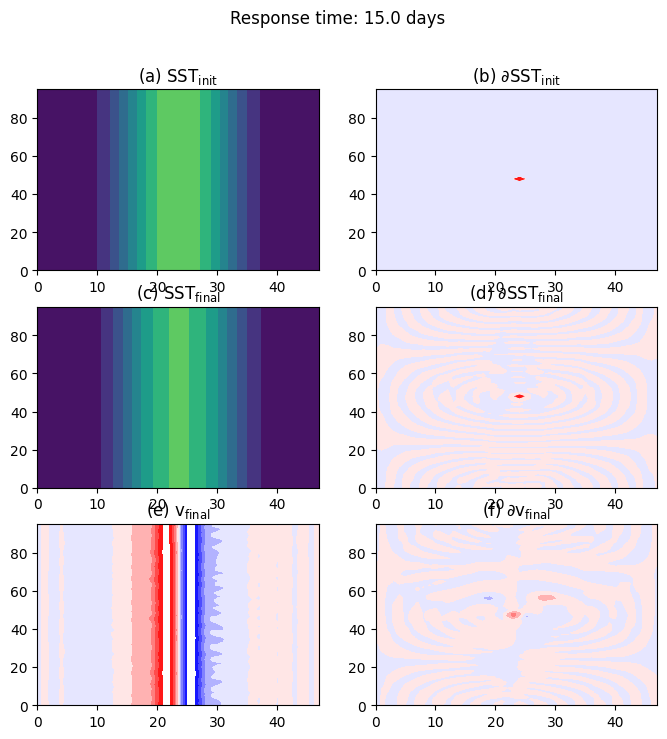

In [10]:
fig, ax = plt.subplots(3, 2, figsize=(8,8))

sst_levels = jnp.linspace(-2, 35, 11)
tangent_sst_levels = jnp.linspace(-1, 1, 11) * 0.5
v_levels = jnp.linspace(-1, 1, 11) * 2
tangent_v_levels = jnp.linspace(-1, 1, 11) * 0.2

ax[0, 0].contourf(sst_initial-273.15, levels=sst_levels)
ax[0, 1].contourf(tangent_sst_initial, levels=tangent_sst_levels, cmap="bwr")
ax[1, 0].contourf(sst_final-273.15, levels=sst_levels)
ax[1, 1].contourf(tangent_sst_final, levels=tangent_sst_levels, cmap="bwr")
ax[2, 0].contourf(v_final, levels=v_levels, cmap="bwr")
ax[2, 1].contourf(tangent_v_final, levels=tangent_v_levels, cmap="bwr")

ax[0, 0].set_title("(a) $\\mathrm{SST}_\\mathrm{init}$")
ax[0, 1].set_title("(b) $\\partial \\mathrm{SST}_\\mathrm{init}$")
ax[1, 0].set_title("(c) $\\mathrm{SST}_\\mathrm{final}$")
ax[1, 1].set_title("(d) $\\partial \\mathrm{SST}_\\mathrm{final}$")
ax[2, 0].set_title("(e) $\\mathrm{v}_\\mathrm{final}$")
ax[2, 1].set_title("(f) $\\partial \\mathrm{v}_\\mathrm{final}$")

fig.suptitle(f"Response time: {simulation_interval / jdt.to_timedelta(1, 'day'):.1f} days")

plt.show()